In [1]:
import numpy as np

N = 256
n = np.arange(N)

# Generar senoide (0 a 255)
x = np.round(127.5 + 127.5 * np.sin(2 * np.pi * n / N)).astype(int)

# Guardar archivo .mem en hexadecimal
with open("sine.mem", "w") as f:
    for val in x:
        f.write(f"{val:02X}\n")

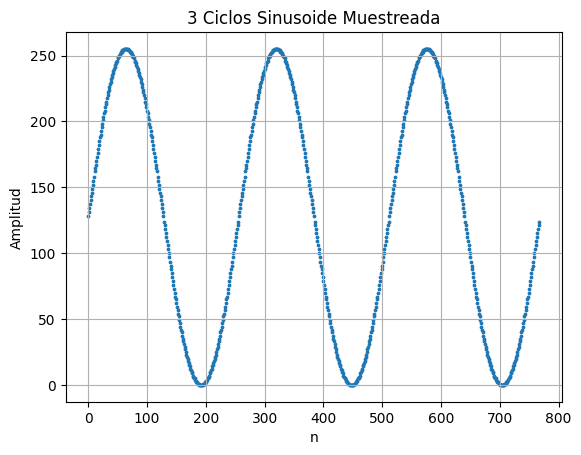

In [7]:
import matplotlib.pyplot as plt

# Leer archivo .mem (hex)
with open("sine.mem", "r") as f:
    lines = f.readlines()

# Convertir a enteros
x = [int(line.strip(), 16) for line in lines]

# Repetir 3 ciclos
x3 = x * 3
n = list(range(len(x3)))

# Graficar puntos pequeños
plt.figure()
plt.scatter(n, x3, s=3)  # 👈 tamaño chico
plt.title("3 Ciclos Sinusoide Muestreada")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.grid()
plt.savefig("Sinusoide_Muestreada.png", dpi = 500)
plt.show()

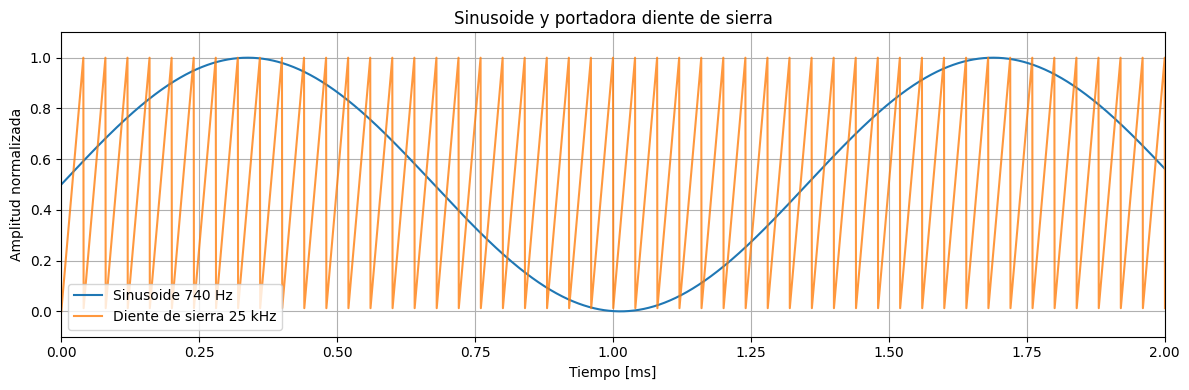

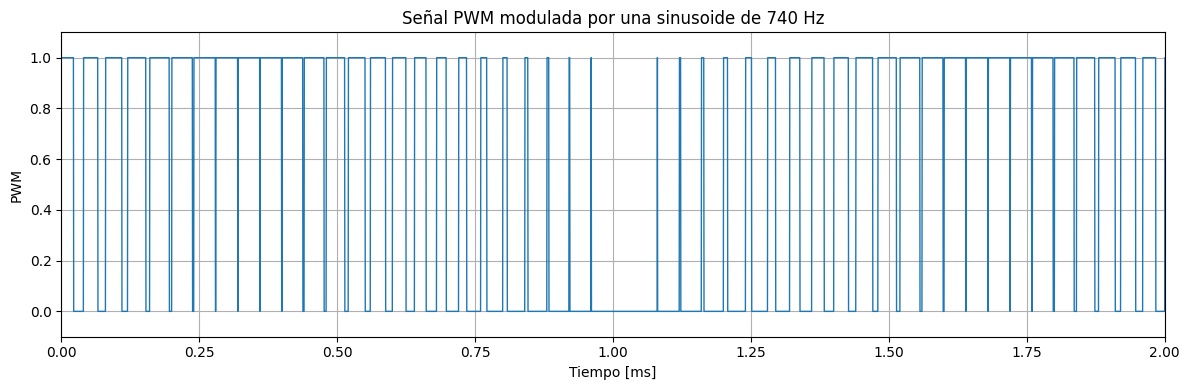

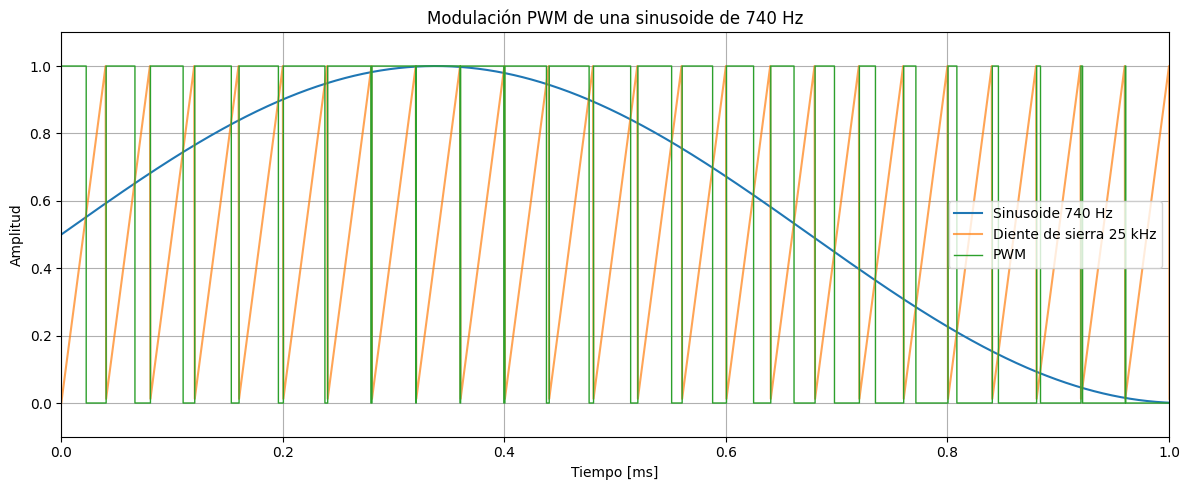

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =========================
# Parámetros
# =========================
f_sin = 740          # Frecuencia de la sinusoide [Hz]
f_saw = 25000        # Frecuencia del diente de sierra [Hz]
fs = 2_000_000       # Frecuencia de muestreo para simulación [Hz]
t_end = 0.005        # Tiempo total de simulación [s]

# =========================
# Eje temporal
# =========================
t = np.arange(0, t_end, 1/fs)

# =========================
# Señal senoidal normalizada entre 0 y 1
# =========================
sinusoidal = 0.5 * (1 + np.sin(2 * np.pi * f_sin * t))

# =========================
# Diente de sierra normalizado entre 0 y 1
# =========================
saw = 0.5 * (1 + signal.sawtooth(2 * np.pi * f_saw * t, width=1.0))

# =========================
# PWM: comparador
# =========================
pwm = (sinusoidal > saw).astype(int)

# =========================
# Gráfico 1: sinusoide y sierra
# =========================
plt.figure(figsize=(12, 4))
plt.plot(t * 1000, sinusoidal, label='Sinusoide 740 Hz')
plt.plot(t * 1000, saw, label='Diente de sierra 25 kHz', alpha=0.8)
plt.xlim(0, 2)  # mostrar 2 ms
plt.ylim(-0.1, 1.1)
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud normalizada')
plt.title('Sinusoide y portadora diente de sierra')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Gráfico 2: PWM resultante
# =========================
plt.figure(figsize=(12, 4))
plt.plot(t * 1000, pwm, linewidth=1)
plt.xlim(0, 2)  # mostrar 2 ms
plt.ylim(-0.1, 1.1)
plt.xlabel('Tiempo [ms]')
plt.ylabel('PWM')
plt.title('Señal PWM modulada por una sinusoide de 740 Hz')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Gráfico 3: todo junto
# =========================
plt.figure(figsize=(12, 5))
plt.plot(t * 1000, sinusoidal, label='Sinusoide 740 Hz')
plt.plot(t * 1000, saw, label='Diente de sierra 25 kHz', alpha=0.7)
plt.step(t * 1000, pwm, where='post', label='PWM', linewidth=1)
plt.xlim(0, 1)  # mostrar 1 ms para mayor detalle
plt.ylim(-0.1, 1.1)
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title('Modulación PWM de una sinusoide de 740 Hz')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()